## Nichtlineare Ausgleichsrechnung, Gauss-Newton und Levenberg-Marquardt
Ein nichtlineares Ausgleichsproblem ist ein Minimierungsproblem

$$
    |\vec{f}(\vec{p})|^2 \stackrel!= \textrm{min}
$$

für eine Funktion $\vec{f}:\mathbb{R}^n \to \mathbb{R}^{N}$. 

### Gauss-Newton Verfahren
Das **Gauss-Newton**-Verfahren ist sehr ähnlich, wie das Newtonverfahren für Gleichungssysteme:
  
* Wähle Startwerte $\vec{p}$
* Für $k = 1, 2, \ldots$
    * Löse das lineare Ausgleichsproblem $|\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 \to \textrm{min}$
    * Setze $\vec{p} := \vec{p} + \vec{\delta}$

$J$ bezeichnet die Jacobimatrix von $\vec{f}$ an der Stelle $\vec{p}$.

Genau wie das Gaussverfahren, kann Gauss-Newton konvergieren oder auch nicht, ahängig von der konkreten Aufgabe und dem Startwert $\vec{p}$. Die Idee dahinter ist, dass

$$
    \vec{f}(\vec{p} + \vec{\delta}) \approx \vec{f}(\vec{p}) + J \vec{\delta}
$$

### Levenberg-Marquardt Verfahren
Das **Levenberg-Marquardt** Verfahren ist eine Erweiterung von Gauss-Newton mit dem Ziel, robustere Konvergenz zu erreichen.

* Wähle $0 < \beta_0 < \beta_1$. Diese Parameter bleiben während der Iteration konstant.
* Wähle Startwert $\vec{p}$ und $\mu > 0$
* Für $k = 1, 2, \ldots$
    * Löse das lineare Ausgleichsproblem $|\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 + \mu^2 |\vec{\delta}|^2 \to \textrm{min}$
    * Berechne $\rho$ (s. unten)
    * Falls $\rho < \beta_0$: setze $\mu := 2 \mu$ (und behalte $\vec{p}$, d.h. das berechnete $\delta$ wird verworfen)
    * Falls $\beta_0 \leq \rho < \beta_1$: setze $\vec{p} := \vec{p} + \vec{\delta}$ (und behalte $\mu$)
    * Falls $\beta_1 < \rho$: setze $\mu := \mu/2$ und $\vec{p} := \vec{p} + \vec{\delta}$   

Die Idee der Minimierung ist, die "Schrittweite" $|\delta|$ zu beschränken, indem der Zusatzterm $\mu^2 |\vec{\delta}|^2$ in die Minimierung einfliesst.  
 
Die Berechnung von $\rho$ ist

$$
    \rho = \frac{|\vec{f}(\vec{p})|^2 - |\vec{f}(\vec{p} + \vec{\delta})|^2}{|\vec{f}(\vec{p})|^2 - |\vec{f}(\vec{p}) + J\, \vec{\delta}|^2}
$$

Hier ist die Idee, die echte Verbesserung (Zähler) mit der effektiv erreichten Verbesserung (Nenner) zu vergleichen 

### Beispiel

Gegeben sind die Daten  

| t   | 0   | 1   | 2   | 3   | 4   | 5   | 6   | 7   | 8   | 9   | 10  |  
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | 
| y   | 0.4 | 0.5 | 1.3 | 1.8 | 2.8 | 3.6 | 4.5 | 4.5 | 4.7 | 4.9 | 5.1 | 


für das Modell

$$
     y_i = \frac{1}{a + b \cdot e^{-c t_i}}
$$

mit den Parameter $a, b, c$. Die Ableitungen von $y$ (nach den drei Parametern) sind

$$
    \vec{\nabla} y_{i} = \frac{1}{(a + b \cdot e^{-c \cdot t_i})^2} \Big( -1, -e^{- c t_i}, b \cdot t_i \cdot e^{- c \cdot t_i}\Big) 
$$




### Hilfsfunktion: (lineares) least-squares mit (numpy) QR

In [2]:
import numpy as np
from scipy.linalg import solve_triangular

def lstsq(A, b):
    Q, R = np.linalg.qr(A)
    z = Q.T@b
    return solve_triangular(R, z)

### Gauss Newton 
Das folgende Skript löst das Ausgleichsproblem mit Gauss-Newton:

p     = [0.1 2.  0.5] 	delta =  [ 0.05507315 -0.17226467  0.02537364]
p     = [0.15507315 1.82773533 0.52537364] 	delta =  [0.04090952 0.48135809 0.12822444]
p     = [0.19598267 2.30909342 0.65359808] 	delta =  [0.00318942 0.49887509 0.07260793]
p     = [0.19917209 2.80796851 0.726206  ] 	delta =  [-0.00041901  0.115483    0.00546   ]
p     = [0.19875308 2.92345151 0.731666  ] 	delta =  [2.28054103e-05 7.45273413e-03 5.09664569e-04]
p     = [0.19877588 2.93090424 0.73217567] 	delta =  [8.22549742e-07 2.34356449e-04 2.14351443e-05]
p     = [0.19877671 2.9311386  0.7321971 ] 	delta =  [1.96113028e-08 6.97454743e-06 6.21133228e-07]
p     = [0.19877673 2.93114557 0.73219772] 	delta =  [6.15754905e-10 2.09063318e-07 1.88338101e-08]
p     = [0.19877673 2.93114578 0.73219774] 	delta =  [1.81485003e-11 6.25719937e-09 5.61668775e-10]
p     = [0.19877673 2.93114579 0.73219774] 	delta =  [5.46125051e-13 1.87371138e-10 1.68384569e-11]


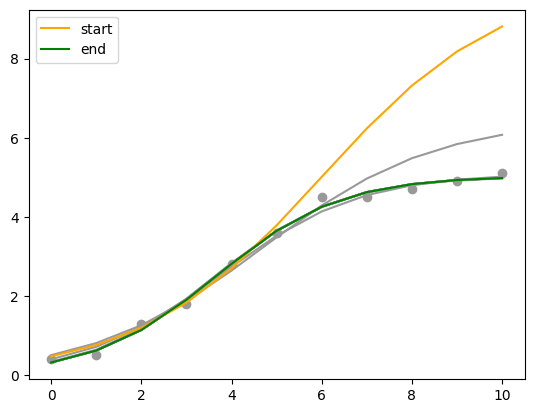

In [8]:
import matplotlib.pyplot as plt

t = np.arange(11)
y = np.array([.4, .5, 1.3, 1.8, 2.8, 3.6, 4.5, 4.5, 4.7, 4.9, 5.1])


f = lambda a, b, c: 1 / ( a + b * np.exp(-c*t) )

J = lambda a, b, c:  (np.array([-np.ones_like(t), -np.exp(-c*t), b*t*np.exp(-c*t)]) / (a + b*np.exp(-c*t))**2).T

p0 = np.array([.1, 2, .5]) # Startwerte für p
# p0 = np.array([.1, .1, .1])

p = p0.copy()
for k in range(10):
    delta = lstsq(J(*p), y-f(*p)) # das Modell wäre f(p) - y = 0 -> Ausgleichsproblem: min J*d + (f(p) - y)
    print("p     =", p, "\tdelta = ", delta)
    p += delta
    plt.plot(t, f(*p), color = [.6,.6,.6])

plt.scatter(t, y, color = [.6,.6,.6])
plt.plot(t, f(*p0), color = "orange", label = "start")
plt.plot(t, f(*p), color = "green", label = "end")

plt.legend()



### Beispiel Ausgleichskreis
Gegeben sind Punkte $(x_i, y_i)$, die ungefähr auf einem Kreis mit unbekanntem Mittelpunkt und Radius liegen. Die Parameter sind also

$$
    \vec{p} = (r, m_x, m_y)
$$

und das Modell

$$
    (x_i - m_x)^2 + (y_i - m_y)^2 = r^2 \quad \implies \quad
    f_i(m_x, m_y, r) = - 2 x_i \, {\color{blue} m_x} + {\color{blue} m_x^2} - 2 y_i \, {\color{blue} m_y} + {\color{blue} m_y^2} - {\color{blue} r^2} + x_i^2 + y_i^2 = 0 \quad (i = 1 \ldots N)
$$

Das Modell ist nichtlinear in $m_x, m_y, r$ mit Jacobimatrix

$$
    [- 2 x_i + 2 m_x, \,\, - 2 y_i + 2 m_y, \, \, - 2 r]  \quad (i = 1 \ldots N)
$$

**Bemerkung**: Das Ausgleichsproblem könnte linearisiert werden, indem man die neuen Parameter 

$$
    \vec{q} = (m_x, m_y, m_x^2 + m_y^2 - r^2) 
$$

verwendet.

p     = [0. 0. 1.] 	delta =  [  3.02299396  -6.99478793 -25.04866348]
p     = [  3.02299396  -6.99478793 -24.04866348] 	delta =  [-1.96440373e-15 -4.82300118e-15  1.18378718e+01]
p     = [  3.02299396  -6.99478793 -12.21079166] 	delta =  [-1.30960249e-15  5.92109520e-15  5.73817051e+00]
p     = [ 3.02299396 -6.99478793 -6.47262114] 	delta =  [ 1.22775233e-16 -8.28953329e-16  2.54352913e+00]
p     = [ 3.02299396 -6.99478793 -3.92909201] 	delta =  [-2.04625389e-16 -3.31043050e-16  8.23286959e-01]
p     = [ 3.02299396 -6.99478793 -3.10580506] 	delta =  [-2.03346480e-16 -3.74441986e-16  1.09118474e-01]
p     = [ 3.02299396 -6.99478793 -2.99668658] 	delta =  [-2.09261433e-16 -3.71913536e-16  1.98666779e-03]
p     = [ 3.02299396 -6.99478793 -2.99469991] 	delta =  [-2.09164314e-16 -3.68126534e-16  6.58972353e-07]
p     = [ 3.02299396 -6.99478793 -2.99469925] 	delta =  [-2.10648562e-16 -3.71359284e-16  7.27737132e-14]
p     = [ 3.02299396 -6.99478793 -2.99469925] 	delta =  [-2.12387748e-16 -3.

(np.float64(-0.46666711999414795),
 np.float64(6.495497090358868),
 np.float64(-10.524402307417864),
 np.float64(-3.5061801278688214))

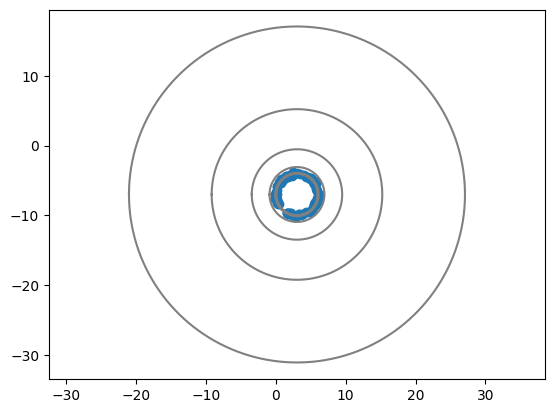

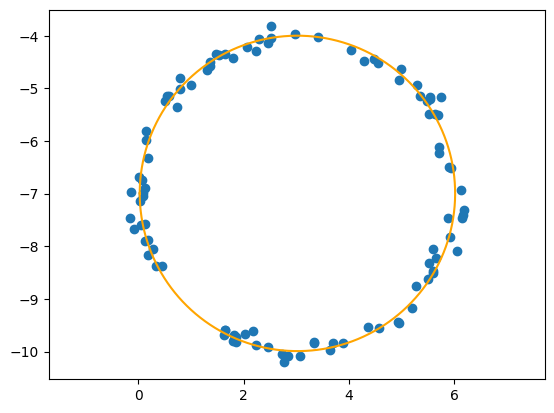

In [24]:
N = 100
a = np.random.rand(N) * 2 * np.pi
r = 3
s = 0.1 # noise
mx, my = 3, -7
xi, yi = mx + r * np.cos(a) + s * np.random.randn(N), my + r * np.sin(a) + + s * np.random.randn(N)

f = lambda mx, my, r: (xi - mx)**2 + (yi - my)**2 - r**2
J = lambda mx, my, r: 2 * np.array([mx - xi, my - yi, - r * np.ones_like(xi)]).T

p = np.array([0., 0., 1]) # Startwerte

# Hilfsfunktion Kreis zeichnen
def circ(mx, my, r, col = "gray"):
    w = np.linspace(0, 1, 500)*2*np.pi
    plt.plot(mx + r * np.cos(w), my + r * np.sin(w), color = col)

for k in range(10):
    delta = lstsq(J(*p), -f(*p)) # das Modell wäre f(p) - y = 0 -> Ausgleichsproblem: min J*d + (f(p) - y)
    print("p     =", p, "\tdelta = ", delta)
    p += delta
    circ(*p)
    
plt.scatter(xi, yi)
plt.axis("equal")

plt.figure()
plt.scatter(xi, yi)
circ(*p, "orange")
plt.axis("equal")

### Levenberg Marquardt

0 : f(p) =  10.8234 	 mu =  0.1 	 |delta| =  0.4446032874871564 	 rho =  1.0644384734184382
1 : f(p) =  4.79514 	 mu =  0.05 	 |delta| =  1.9938539719417967 	 rho =  -6.0864558284329195
2 : f(p) =  4.79514 	 mu =  0.1 	 |delta| =  1.978080544900461 	 rho =  -6.105068444971262
3 : f(p) =  4.79514 	 mu =  0.2 	 |delta| =  1.9177295060732542 	 rho =  -6.176203813963621
4 : f(p) =  4.79514 	 mu =  0.4 	 |delta| =  1.7133822144690005 	 rho =  -6.415723771315931
5 : f(p) =  4.79514 	 mu =  0.8 	 |delta| =  1.237994816651668 	 rho =  -6.961248918787382
6 : f(p) =  4.79514 	 mu =  1.6 	 |delta| =  0.7370448244968909 	 rho =  -6.934517174330517
7 : f(p) =  4.79514 	 mu =  3.2 	 |delta| =  0.5175830468973472 	 rho =  -0.661887450789887
8 : f(p) =  4.79514 	 mu =  6.4 	 |delta| =  0.34339432413377885 	 rho =  1.4359898853923794
9 : f(p) =  2.82336 	 mu =  3.2 	 |delta| =  0.37729087960071783 	 rho =  -0.5259915860507474
10 : f(p) =  2.82336 	 mu =  6.4 	 |delta| =  0.19886306900340162 	 rho =  0.

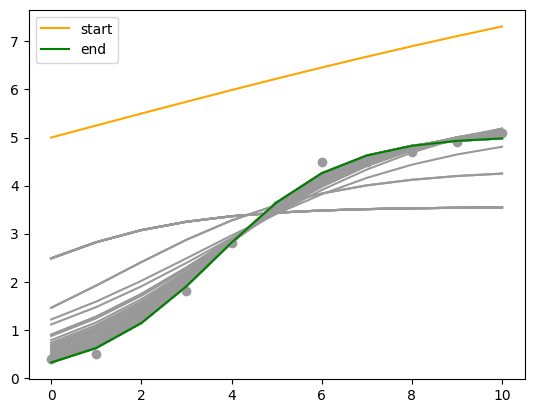

In [5]:
import numpy as np
import matplotlib.pyplot as plt 

t = np.arange(11)
y = np.array([.4, .5, 1.3, 1.8, 2.8, 3.6, 4.5, 4.5, 4.7, 4.9, 5.1])


f = lambda a, b, c: 1 / ( a + b * np.exp(-c*t) )
J = lambda a, b, c:  (np.array([-np.ones_like(t), -np.exp(-c*t), b*t*np.exp(-c*t)]) / (a + b*np.exp(-c*t))**2).T

Je = lambda a, b, c: J(*p)

p0 = np.array([.3, 2, .5])
p0 = np.array([.1, .1, .1])

def rho(f, J, p, delta):
    a = np.linalg.norm(f(*p))**2
    b = np.linalg.norm(f(*p + delta))**2
    c = np.linalg.norm(f(*p) + J(*p) @ delta)**2

    return (a - b) / (1e-12 + a - c) 

p = p0.copy()

def LM(f, J, p, beta0 = 0.2, beta1 = 0.8, mu = 0.1, maxit = 100):

    n = len(p)
    delta = 1
    it = 0

    while np.linalg.norm(delta) > 1e-8 and it < maxit:
        
        Jext = np.concatenate( (J(*p), mu * np.eye(n)) )
        fext = np.concatenate ((y - f(*p), np.zeros(n)) ) # das Modell wäre f(p) - y = 0
        
        delta = lstsq(Jext, fext) # lineares Ausgleichsproblem lösen
        r = rho(f, J, p, delta)
    
        print(it, 
          ": f(p) = ", np.round(np.linalg.norm(y - f(*p)), 5), 
          "\t mu = ", mu, 
          "\t |delta| = ", np.linalg.norm(delta),
          "\t rho = ", r)

    
        if r < beta0:
            mu *= 2
        elif r < beta1:
            p += delta
        else:
            p += delta
            mu /= 2
    
        it += 1

        plt.plot(t, f(*p), color = [.6,.6,.6])

    return p

LM(f, J, p, maxit = 500)

plt.scatter(t, y, color = [.6,.6,.6])
plt.plot(t, f(*p0), color = "orange", label = "start")
plt.plot(t, f(*p), color = "green", label = "end")

plt.legend()

